In [ ]:
# | Core Feature                                      | Main AI/Tech                                 | **Best Model for Our Project**                                               | **Best Dataset / Data Source**                                                    |
# | ------------------------------------------------- | -------------------------------------------- | ---------------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
# | 🌾 **1. Smart Crop Recommendation**               | Pandas, NumPy, Scikit-learn                  | **Random Forest Classifier**                                                 | **Crop Recommendation Dataset** with N, P, K, temperature, humidity, pH, rainfall |
# | 🍃 **2. Plant Disease Detection**                 | OpenCV, TensorFlow                           | **Transfer Learning with EfficientNetB0**                                    | **PlantVillage Dataset**, 54K+ images, 38 classes                                 |
# | 🌱 **3. New Crop & Crop Adaptation Advisor**      | Pandas, NumPy, Scikit-learn + knowledge base | **Random Forest / Gradient Boosting + Crop Requirement Matching Engine**     | **FAO ECOCROP/GAEZ + curated crop requirement data**                              |
# | 🧪 **4. Cultivation & Nutrient Advisory**         | Pandas + rule/knowledge engine               | **Rule-Based Expert System + ML support**                                    | Crop-specific cultivation/fertilizer data from reliable agricultural sources      |
# | 🔬 **5. What-If Crop Suitability Simulator**      | Scikit-learn + NumPy                         | **Random Forest / Gradient Boosting Regressor or Suitability Scoring Model** | Crop requirement data + crop recommendation data + adaptation scenarios           |
# | 📊 **6. Farmer Dashboard & History**              | Pandas, Matplotlib, MongoDB                  | No separate ML model                                                         | **Our application's prediction/history data**                                     |
# | 👨‍🌾 **7. Personalized Agriculture Action Plan** | ML outputs + knowledge/rule engine           | **Hybrid AI: ML + Rule-Based System**                                        | Crop requirements + disease information + cultivation/adaptation knowledge base   |


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/atharvaingle/crop-recommendation-dataset


In [3]:
pip install numpy pandas matplotlib scikit-learn seaborn joblib jupyter

Note: you may need to restart the kernel to use updated packages.


**Start codeing here**

In [4]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================================
# CELL 2: FIND CSV FILES IN KAGGLE INPUT
# ============================================================

csv_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:\n")

for file in csv_files:
    print(file)

CSV files found:

/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv


In [6]:
# ============================================================
# CELL 3: LOAD DATASET
# ============================================================

# Find the Crop Recommendation CSV
crop_csv = None

for file in csv_files:
    if "crop" in file.lower() or "recommend" in file.lower():
        crop_csv = file
        break

if crop_csv is None:
    raise FileNotFoundError(
        "Crop Recommendation CSV not found. "
        "Please add the dataset to the Kaggle notebook."
    )

df = pd.read_csv(crop_csv)

print("Dataset loaded successfully.")
print("Dataset path:", crop_csv)
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset path: /kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv
Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
# ============================================================
# CELL 4: DATASET OVERVIEW
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape:
(2200, 8)

Column Names:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

First 5 Rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Last 5 Rows:


,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [8]:
# ============================================================
# CELL 5: DATA QUALITY CHECK
# ============================================================

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nUnique Values per Column:")
print(df.nunique())

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



Unique Values per Column:
N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64


In [9]:
# ============================================================
# CELL 6: REMOVE DUPLICATES
# ============================================================

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 2200
Rows after removing duplicates: 2200
Duplicates removed: 0


In [10]:
# ============================================================
# CELL 7: CROP CLASS DISTRIBUTION
# ============================================================

crop_counts = df["label"].value_counts().sort_values(ascending=False)

print("Number of crop classes:", df["label"].nunique())

display(crop_counts)

Number of crop classes: 22


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

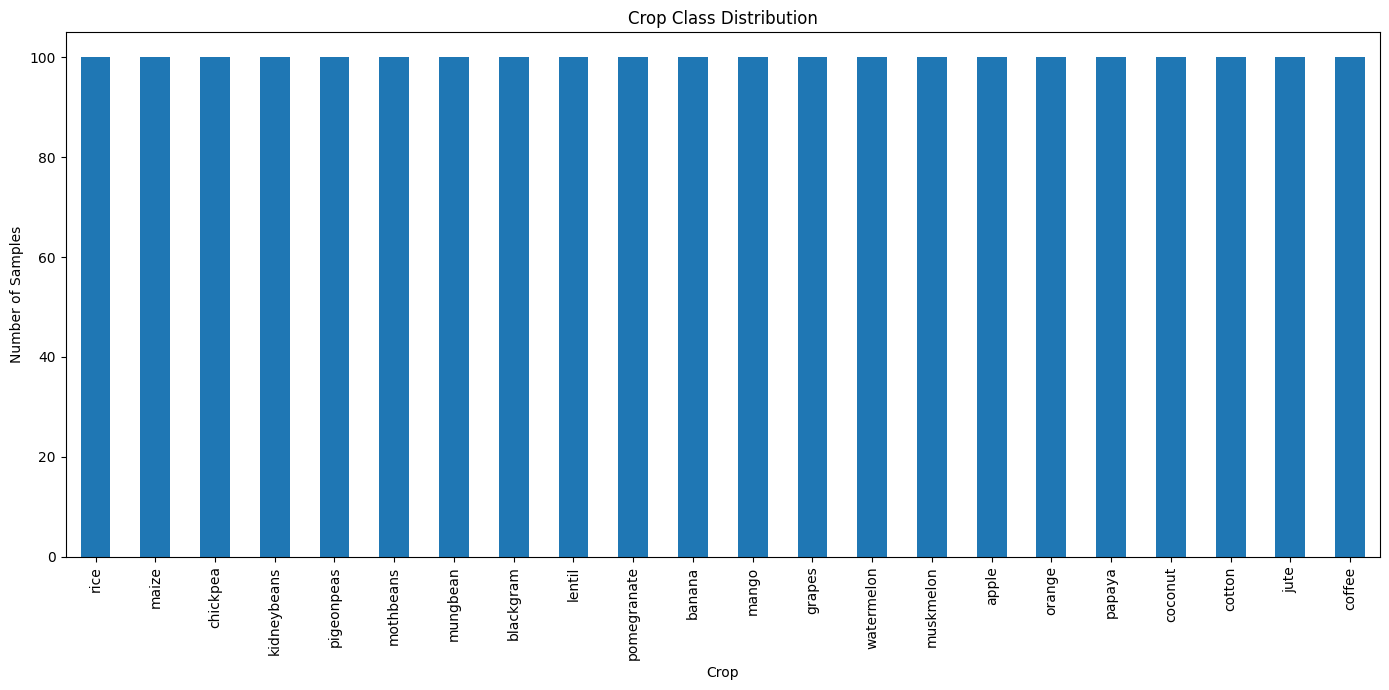

In [11]:
# ============================================================
# CELL 8: CROP DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 7))

crop_counts.plot(kind="bar")

plt.title("Crop Class Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

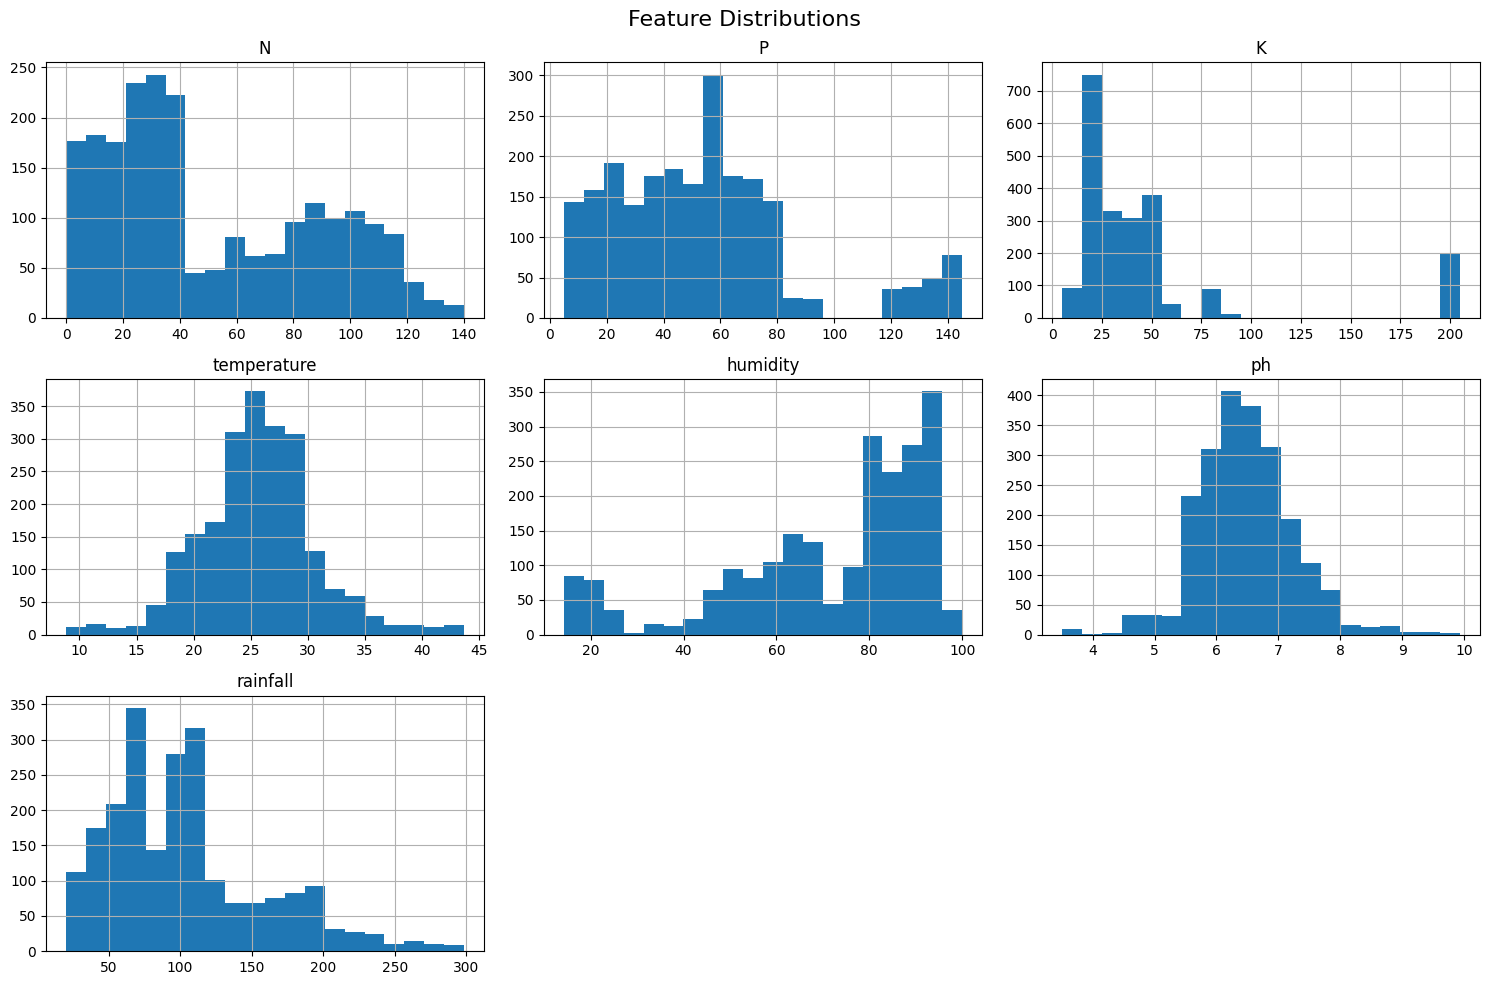

In [12]:
# ============================================================
# CELL 9: FEATURE DISTRIBUTIONS
# ============================================================

numeric_features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

df[numeric_features].hist(
    figsize=(15, 10),
    bins=20
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

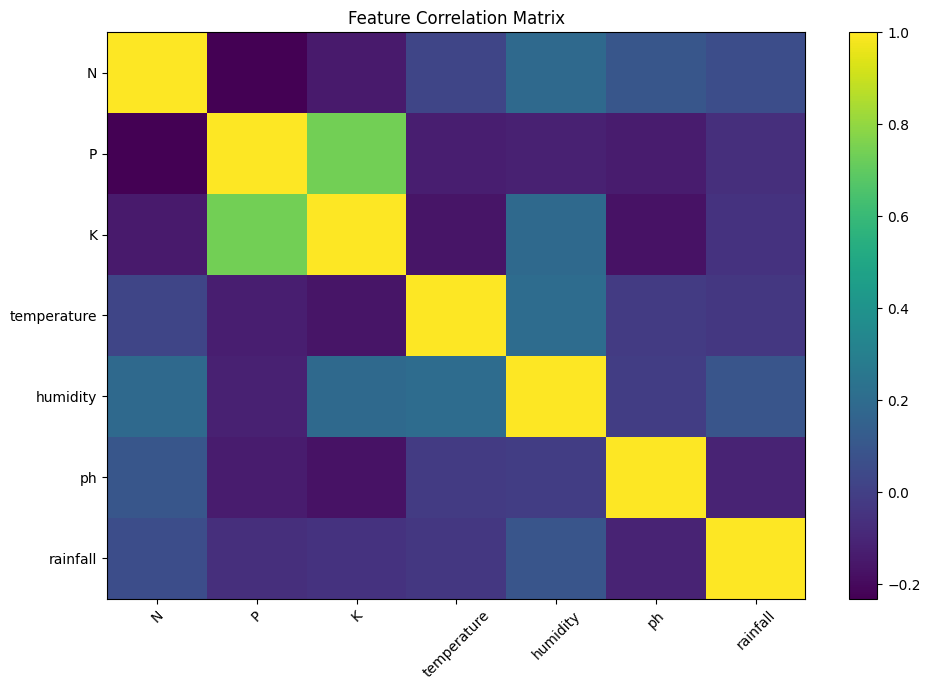

In [13]:
# ============================================================
# CELL 10: CORRELATION MATRIX
# ============================================================

correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(numeric_features)),
    numeric_features,
    rotation=45
)

plt.yticks(
    range(len(numeric_features)),
    numeric_features
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 11: FEATURES AND TARGET
# ============================================================

X = df[numeric_features].copy()

y = df["label"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Feature matrix shape: (2200, 7)
Target shape: (2200,)

Features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Target classes:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [15]:
# ============================================================
# CELL 12: LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of classes:", len(label_encoder.classes_))

print("\nCrop Label Mapping:")

for index, crop in enumerate(label_encoder.classes_):
    print(index, "->", crop)

Number of classes: 22

Crop Label Mapping:
0 -> apple
1 -> banana
2 -> blackgram
3 -> chickpea
4 -> coconut
5 -> coffee
6 -> cotton
7 -> grapes
8 -> jute
9 -> kidneybeans
10 -> lentil
11 -> maize
12 -> mango
13 -> mothbeans
14 -> mungbean
15 -> muskmelon
16 -> orange
17 -> papaya
18 -> pigeonpeas
19 -> pomegranate
20 -> rice
21 -> watermelon


In [16]:
# ============================================================
# CELL 13: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training samples: 1540
Testing samples: 660

Training shape: (1540, 7)
Testing shape: (660, 7)


In [17]:
# ============================================================
# CELL 14: DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models created:")
for model_name in models:
    print("-", model_name)

Models created:
- Logistic Regression
- KNN
- Decision Tree
- SVM
- Random Forest
- Gradient Boosting


In [18]:
# ============================================================
# CELL 15: TRAIN MODELS
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[name] = model

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


Training Logistic Regression...
Accuracy: 0.9727
Precision: 0.9735
Recall: 0.9727
F1 Score: 0.9725

Training KNN...
Accuracy: 0.9788
Precision: 0.9801
Recall: 0.9788
F1 Score: 0.9786

Training Decision Tree...
Accuracy: 0.9788
Precision: 0.9793
Recall: 0.9788
F1 Score: 0.9787

Training SVM...
Accuracy: 0.9894
Precision: 0.9903
Recall: 0.9894
F1 Score: 0.9894

Training Random Forest...
Accuracy: 0.9955
Precision: 0.9956
Recall: 0.9955
F1 Score: 0.9955

Training Gradient Boosting...
Accuracy: 0.9924
Precision: 0.9927
Recall: 0.9924
F1 Score: 0.9924


In [19]:
# ============================================================
# CELL 16: MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.995455,0.995601,0.995455,0.995453
1,Gradient Boosting,0.992424,0.992711,0.992424,0.992420
2,SVM,0.989394,0.990254,0.989394,0.989366
3,Decision Tree,0.978788,0.979319,0.978788,0.978743
4,KNN,0.978788,0.980140,0.978788,0.978619
5,Logistic Regression,0.972727,0.973531,0.972727,0.972543


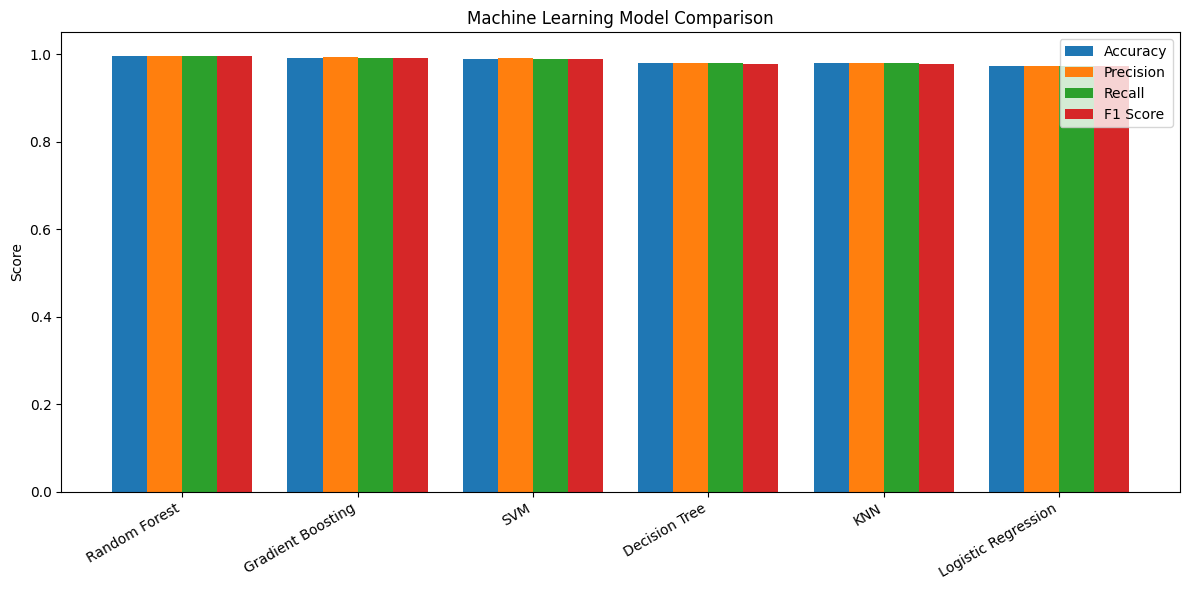

In [20]:
# ============================================================
# CELL 17: MODEL PERFORMANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

plt.bar(
    x - 1.5 * width,
    results_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * width,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + 0.5 * width,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 1.5 * width,
    results_df["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=30,
    ha="right"
)

plt.ylabel("Score")
plt.title("Machine Learning Model Comparison")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CELL 18: SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best candidate model:", best_model_name)
print("F1 Score:", results_df.iloc[0]["F1 Score"])

Best candidate model: Random Forest
F1 Score: 0.9954532824774558


**Hyperparameter Tuning**

In [22]:
# ============================================================
# CELL 19: RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV F1 Score:
0.9954453975143629


In [23]:
# ============================================================
# CELL 20: FINAL MODEL
# ============================================================

final_model = grid_search.best_estimator_

print("Final model:")
print(final_model)

Final model:
RandomForestClassifier(n_jobs=-1, random_state=42)


In [24]:
# ============================================================
# CELL 21: FINAL MODEL EVALUATION
# ============================================================

y_pred = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)

final_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Final Model Performance")
print("=" * 40)

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")

Final Model Performance
Accuracy  : 0.9939
Precision : 0.9942
Recall    : 0.9939
F1 Score  : 0.9939


In [25]:
# ============================================================
# CELL 22: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       1.00      0.97      0.98        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        30
      grapes       1.00      1.00      1.00        30
        jute       0.94      1.00      0.97        30
 kidneybeans       1.00      1.00      1.00        30
      lentil       1.00      0.97      0.98        30
       maize       0.97      1.00      0.98        30
       mango       1.00      1.00      1.00        30
   mothbeans       0.97      1.00      0.98        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
      papaya       1.00    

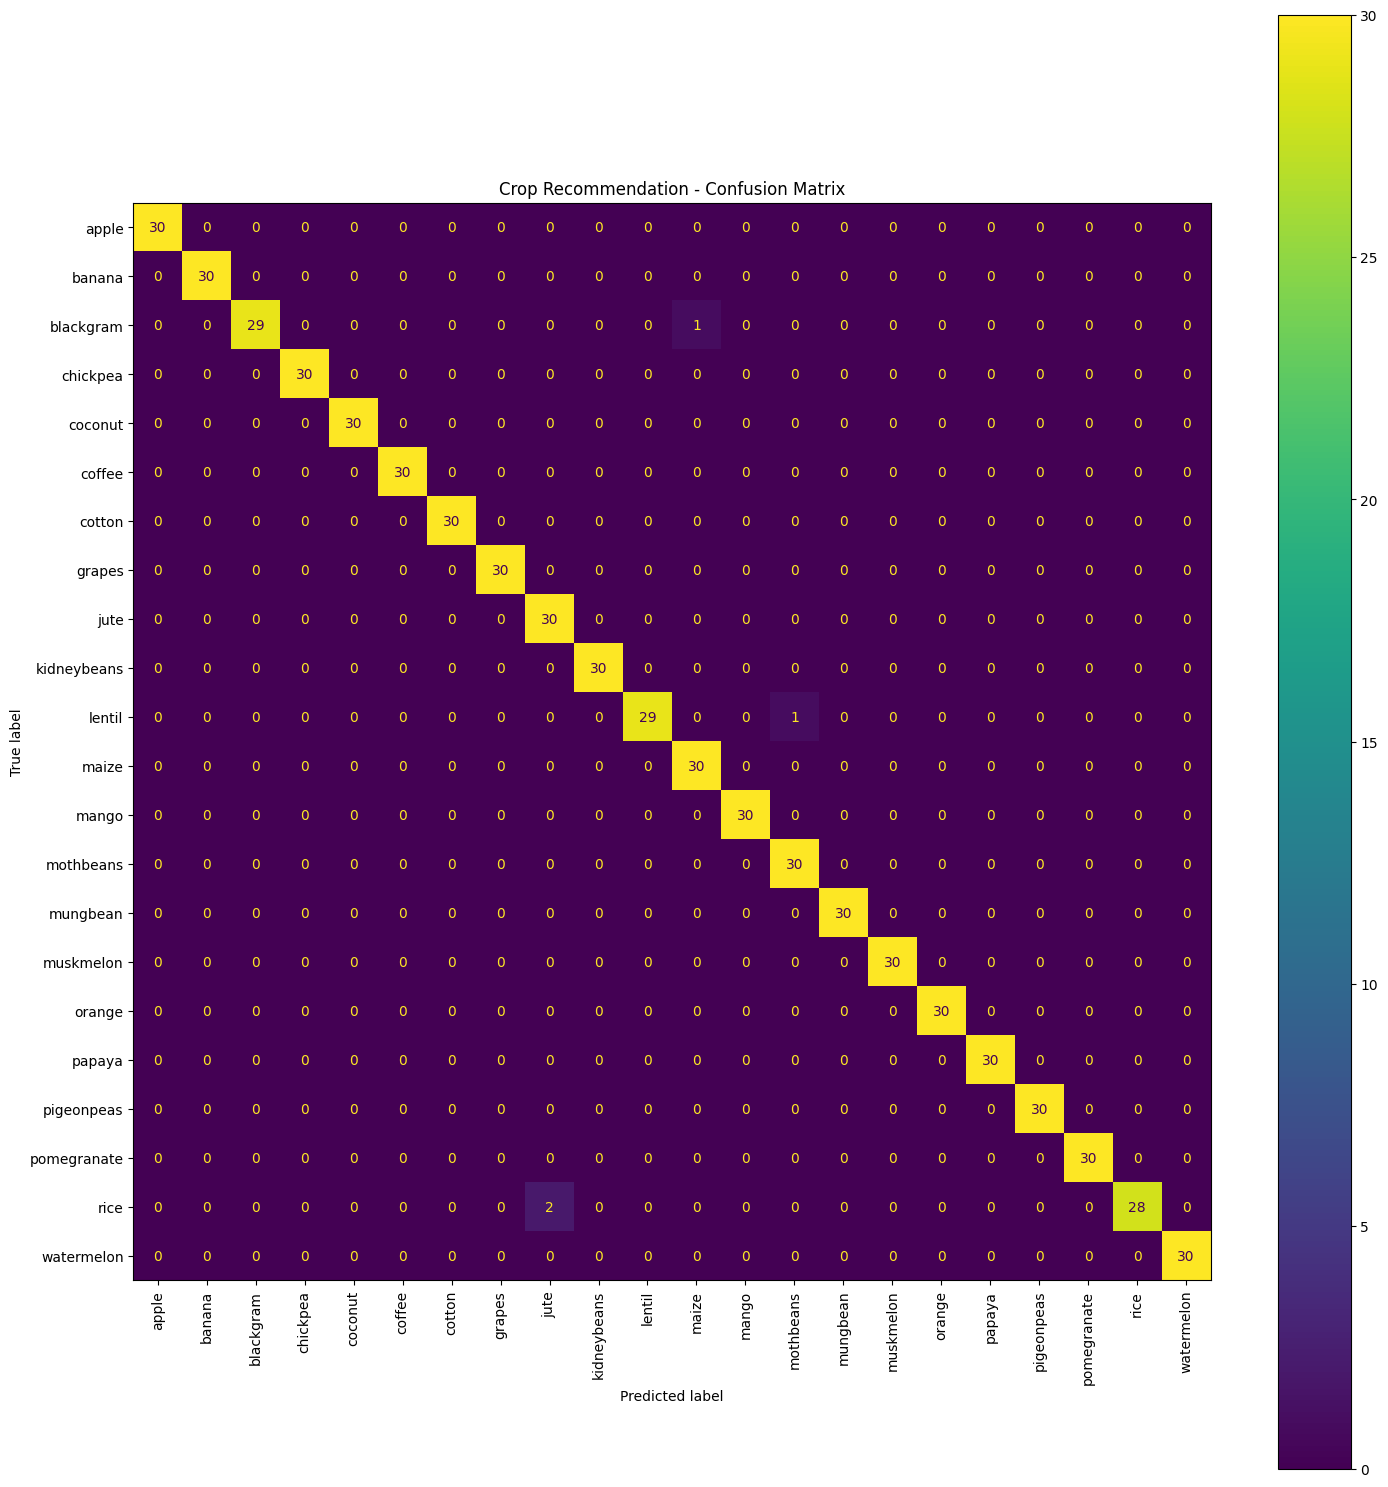

In [26]:
# ============================================================
# CELL 23: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(15, 15))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Crop Recommendation - Confusion Matrix")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# CELL 24: FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
6,rainfall,0.225824
4,humidity,0.213526
2,K,0.170647
1,P,0.153043
0,N,0.108487
3,temperature,0.076468
5,ph,0.052006


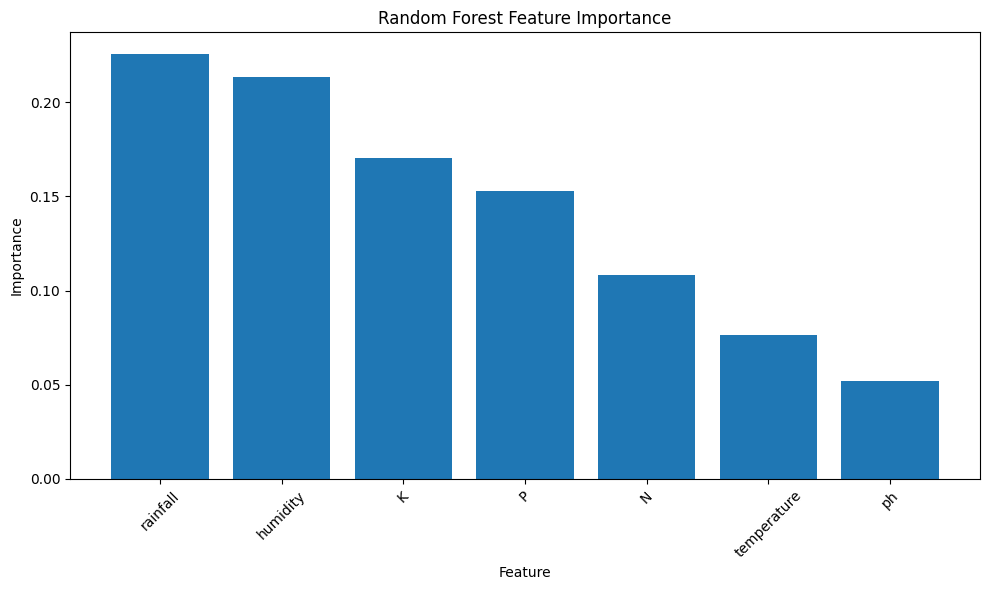

In [28]:
# ============================================================
# CELL 25: FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Prediction**

In [29]:
# ============================================================
# CELL 26: SAMPLE PREDICTION
# ============================================================

sample = pd.DataFrame(
    [[
        90,     # Nitrogen
        42,     # Phosphorus
        43,     # Potassium
        25.5,   # Temperature
        80.0,   # Humidity
        6.5,    # pH
        200.0   # Rainfall
    ]],
    columns=numeric_features
)

predicted_class = final_model.predict(sample)[0]

predicted_crop = label_encoder.inverse_transform(
    [predicted_class]
)[0]

print("Predicted Crop:", predicted_crop)

Predicted Crop: rice


In [30]:
# ============================================================
# CELL 27: PREDICTION PROBABILITIES
# ============================================================

probabilities = final_model.predict_proba(sample)[0]

probability_df = pd.DataFrame({
    "Crop": label_encoder.classes_,
    "Probability": probabilities
})

probability_df = probability_df.sort_values(
    by="Probability",
    ascending=False
)

display(probability_df.head(10))

,Crop,Probability
20,rice,0.56
8,jute,0.44
2,blackgram,0.00
3,chickpea,0.00
0,apple,0.00
1,banana,0.00
5,coffee,0.00
4,coconut,0.00
7,grapes,0.00
6,cotton,0.00


In [31]:
# ============================================================
# CELL 28: TOP 5 CROP RECOMMENDATIONS
# ============================================================

top_5 = probability_df.head(5).copy()

top_5["Probability (%)"] = (
    top_5["Probability"] * 100
).round(2)

display(
    top_5[
        ["Crop", "Probability (%)"]
    ]
)

,Crop,Probability (%)
20,rice,56.0
8,jute,44.0
2,blackgram,0.0
3,chickpea,0.0
0,apple,0.0


In [32]:
# ============================================================
# CELL 29: MULTIPLE SAMPLE PREDICTIONS
# ============================================================

test_samples = pd.DataFrame([
    [90, 42, 43, 25.5, 80.0, 6.5, 200.0],
    [70, 40, 40, 22.0, 70.0, 6.0, 150.0],
    [100, 20, 30, 28.0, 75.0, 6.8, 220.0],
    [50, 30, 20, 20.0, 60.0, 6.2, 100.0]
], columns=numeric_features)

predictions = final_model.predict(test_samples)

predicted_crops = label_encoder.inverse_transform(
    predictions
)

prediction_results = test_samples.copy()

prediction_results["Recommended Crop"] = predicted_crops

display(prediction_results)

,N,P,K,temperature,humidity,ph,rainfall,Recommended Crop
0,90,42,43,25.5,80.0,6.5,200.0,rice
1,70,40,40,22.0,70.0,6.0,150.0,jute
2,100,20,30,28.0,75.0,6.8,220.0,coffee
3,50,30,20,20.0,60.0,6.2,100.0,mango


In [33]:
# ============================================================
# CELL 30: CREATE MODEL DIRECTORY
# ============================================================

model_dir = "/kaggle/working/models/crop_recommendation"

os.makedirs(
    model_dir,
    exist_ok=True
)

print("Model directory:", model_dir)

Model directory: /kaggle/working/models/crop_recommendation


In [34]:
# ============================================================
# CELL 31: SAVE FINAL MODEL
# ============================================================

model_path = os.path.join(
    model_dir,
    "crop_model.pkl"
)

with open(model_path, "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
/kaggle/working/models/crop_recommendation/crop_model.pkl


In [35]:
# ============================================================
# CELL 32: SAVE LABEL ENCODER
# ============================================================

encoder_path = os.path.join(
    model_dir,
    "label_encoder.pkl"
)

with open(encoder_path, "wb") as file:
    pickle.dump(label_encoder, file)

print("Label encoder saved:")
print(encoder_path)

Label encoder saved:
/kaggle/working/models/crop_recommendation/label_encoder.pkl


In [36]:
# ============================================================
# CELL 33: SAVE FEATURE INFORMATION
# ============================================================

feature_info = {
    "features": numeric_features,
    "target": "label",
    "num_classes": len(label_encoder.classes_),
    "classes": label_encoder.classes_.tolist()
}

feature_info_path = os.path.join(
    model_dir,
    "feature_info.json"
)

with open(feature_info_path, "w") as file:
    json.dump(
        feature_info,
        file,
        indent=4
    )

print("Feature information saved:")
print(feature_info_path)

Feature information saved:
/kaggle/working/models/crop_recommendation/feature_info.json


In [37]:
# ============================================================
# CELL 34: SAVE MODEL METRICS
# ============================================================

metrics = {
    "model": "RandomForestClassifier",
    "accuracy": float(final_accuracy),
    "precision": float(final_precision),
    "recall": float(final_recall),
    "f1_score": float(final_f1),
    "best_parameters": grid_search.best_params_
}

metrics_path = os.path.join(
    model_dir,
    "model_metrics.json"
)

with open(metrics_path, "w") as file:
    json.dump(
        metrics,
        file,
        indent=4
    )

print("Model metrics saved:")
print(metrics_path)

Model metrics saved:
/kaggle/working/models/crop_recommendation/model_metrics.json


In [38]:
# ============================================================
# CELL 35: LOAD AND VERIFY SAVED MODEL
# ============================================================

with open(model_path, "rb") as file:
    loaded_model = pickle.load(file)

with open(encoder_path, "rb") as file:
    loaded_encoder = pickle.load(file)

loaded_prediction = loaded_model.predict(sample)

loaded_crop = loaded_encoder.inverse_transform(
    loaded_prediction
)[0]

print("Loaded model prediction:", loaded_crop)
print("Original model prediction:", predicted_crop)

if loaded_crop == predicted_crop:
    print("\nModel verification: PASSED")
else:
    print("\nModel verification: FAILED")

Loaded model prediction: rice
Original model prediction: rice

Model verification: PASSED


In [39]:
# ============================================================
# CELL 36: FINAL SUMMARY
# ============================================================

print("=" * 60)
print("CROP RECOMMENDATION MODEL - FINAL SUMMARY")
print("=" * 60)

print(f"Dataset Shape       : {df.shape}")
print(f"Number of Classes   : {len(label_encoder.classes_)}")
print(f"Training Samples    : {len(X_train)}")
print(f"Testing Samples     : {len(X_test)}")

print("\nFinal Model:")
print("Random Forest Classifier")

print("\nPerformance:")
print(f"Accuracy            : {final_accuracy:.4f}")
print(f"Precision           : {final_precision:.4f}")
print(f"Recall              : {final_recall:.4f}")
print(f"F1 Score            : {final_f1:.4f}")

print("\nSaved Files:")
print("crop_model.pkl")
print("label_encoder.pkl")
print("feature_info.json")
print("model_metrics.json")

print("\nModel training completed successfully.")

CROP RECOMMENDATION MODEL - FINAL SUMMARY
Dataset Shape       : (2200, 8)
Number of Classes   : 22
Training Samples    : 1540
Testing Samples     : 660

Final Model:
Random Forest Classifier

Performance:
Accuracy            : 0.9939
Precision           : 0.9942
Recall              : 0.9939
F1 Score            : 0.9939

Saved Files:
crop_model.pkl
label_encoder.pkl
feature_info.json
model_metrics.json

Model training completed successfully.


In [40]:
# ============================================================
# CELL 37: LIST SAVED FILES
# ============================================================

for root, dirs, files in os.walk(model_dir):

    for file in files:
        full_path = os.path.join(root, file)

        print(
            file,
            "->",
            round(os.path.getsize(full_path) / 1024, 2),
            "KB"
        )

label_encoder.pkl -> 0.46 KB
model_metrics.json -> 0.33 KB
feature_info.json -> 0.62 KB
crop_model.pkl -> 3437.33 KB


In [41]:
import os
import zipfile

model_dir = "/kaggle/working/models/crop_recommendation"
zip_path = "/kaggle/working/crop_recommendation_model.zip"

files_to_zip = [
    "crop_model.pkl",
    "label_encoder.pkl",
    "feature_info.json",
    "model_metrics.json"
]

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:

    for filename in files_to_zip:
        file_path = os.path.join(model_dir, filename)

        if os.path.exists(file_path):
            zipf.write(
                file_path,
                arcname=f"crop_recommendation/{filename}"
            )
        else:
            print(f"WARNING: {filename} not found")

print("ZIP created successfully!")
print(zip_path)

print("\nZIP contents:")
with zipfile.ZipFile(zip_path, "r") as zipf:
    for file in zipf.namelist():
        print(file)

ZIP created successfully!
/kaggle/working/crop_recommendation_model.zip

ZIP contents:
crop_recommendation/crop_model.pkl
crop_recommendation/label_encoder.pkl
crop_recommendation/feature_info.json
crop_recommendation/model_metrics.json


In [43]:
# ============================================================
# FINAL CROP RECOMMENDATION DEPLOYMENT PACKAGE
# ============================================================

import os
import json
import sys
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
import sklearn


# ============================================================
# 1. PATHS
# ============================================================

model_dir = "/kaggle/working/models/crop_recommendation"
zip_path = "/kaggle/working/crop_recommendation_model.zip"

os.makedirs(model_dir, exist_ok=True)

print("Model directory:")
print(model_dir)


# ============================================================
# 2. CHECK REQUIRED MODEL FILES
# ============================================================

required_files = [
    "crop_model.pkl",
    "label_encoder.pkl",
    "feature_info.json",
    "model_metrics.json"
]

missing_files = []

for filename in required_files:

    filepath = os.path.join(model_dir, filename)

    if not os.path.exists(filepath):
        missing_files.append(filename)


if missing_files:

    print("\nMissing files:")

    for filename in missing_files:
        print(" -", filename)

    raise FileNotFoundError(
        "Required model files are missing. "
        "Run the model training and saving cells first."
    )


print("\nAll required model files found.")


# ============================================================
# 3. GET ENVIRONMENT VERSIONS
# ============================================================

python_version = sys.version.split()[0]
numpy_version = np.__version__
pandas_version = pd.__version__
sklearn_version = sklearn.__version__

print("\nEnvironment:")
print("Python:", python_version)
print("NumPy:", numpy_version)
print("Pandas:", pandas_version)
print("Scikit-learn:", sklearn_version)


# ============================================================
# 4. CREATE requirements.txt
# ============================================================

requirements = (
    f"numpy=={numpy_version}\n"
    f"pandas=={pandas_version}\n"
    f"scikit-learn=={sklearn_version}\n"
)

requirements_path = os.path.join(
    model_dir,
    "requirements.txt"
)

with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(requirements)

print("\nCreated:", requirements_path)


# ============================================================
# 5. CREATE FULL REQUIREMENTS
# ============================================================

full_requirements_path = os.path.join(
    model_dir,
    "requirements-full.txt"
)

os.system(
    f'pip freeze > "{full_requirements_path}"'
)

print("Created:", full_requirements_path)


# ============================================================
# 6. CREATE SAMPLE INPUT
# ============================================================

sample_input = {
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 25.5,
    "humidity": 80.0,
    "ph": 6.5,
    "rainfall": 200.0
}

sample_input_path = os.path.join(
    model_dir,
    "sample_input.json"
)

with open(
    sample_input_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        sample_input,
        file,
        indent=4
    )

print("Created:", sample_input_path)


# ============================================================
# 7. LOAD MODEL METADATA
# ============================================================

feature_info_path = os.path.join(
    model_dir,
    "feature_info.json"
)

metrics_path = os.path.join(
    model_dir,
    "model_metrics.json"
)

with open(
    feature_info_path,
    "r",
    encoding="utf-8"
) as file:

    feature_info = json.load(file)


with open(
    metrics_path,
    "r",
    encoding="utf-8"
) as file:

    model_metrics = json.load(file)


# ============================================================
# 8. CREATE MODEL VERSION
# ============================================================

model_version = {
    "model_name": "crop_recommendation",
    "model_type": "RandomForestClassifier",
    "version": "1.0.0",
    "training_date": datetime.now().strftime("%Y-%m-%d"),
    "framework": "scikit-learn",

    "python_version": python_version,

    "libraries": {
        "numpy": numpy_version,
        "pandas": pandas_version,
        "scikit-learn": sklearn_version
    },

    "input_features": feature_info.get(
        "features",
        [
            "N",
            "P",
            "K",
            "temperature",
            "humidity",
            "ph",
            "rainfall"
        ]
    ),

    "target": feature_info.get(
        "target",
        "label"
    ),

    "num_classes": feature_info.get(
        "num_classes",
        len(feature_info.get("classes", []))
    ),

    "performance": {
        "accuracy": model_metrics.get("accuracy"),
        "precision": model_metrics.get("precision"),
        "recall": model_metrics.get("recall"),
        "f1_score": model_metrics.get("f1_score")
    }
}

model_version_path = os.path.join(
    model_dir,
    "model_version.json"
)

with open(
    model_version_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_version,
        file,
        indent=4
    )

print("Created:", model_version_path)


# ============================================================
# 9. CREATE README
# ============================================================

readme_lines = [
    "# Crop Recommendation Model",
    "",
    "## Model Information",
    "",
    "- Model Name: Crop Recommendation",
    "- Model Type: Random Forest Classifier",
    "- Version: 1.0.0",
    "- Framework: scikit-learn",
    f"- Training Date: {datetime.now().strftime('%Y-%m-%d')}",
    "",
    "## Input Features",
    "",
    "The model expects the following features:",
    "",
    "1. N - Nitrogen",
    "2. P - Phosphorus",
    "3. K - Potassium",
    "4. temperature - Temperature",
    "5. humidity - Humidity",
    "6. ph - Soil pH",
    "7. rainfall - Rainfall",
    "",
    "## Example Input",
    "",
    "N = 90",
    "P = 42",
    "K = 43",
    "temperature = 25.5",
    "humidity = 80.0",
    "ph = 6.5",
    "rainfall = 200.0",
    "",
    "## Model Output",
    "",
    "The model predicts a recommended crop.",
    "",
    "The Random Forest model can also provide class",
    "probabilities using predict_proba().",
    "",
    "These probabilities are model estimates and should",
    "not be interpreted as guarantees of crop success.",
    "",
    "## Files",
    "",
    "- crop_model.pkl",
    "- label_encoder.pkl",
    "- feature_info.json",
    "- model_metrics.json",
    "- requirements.txt",
    "- requirements-full.txt",
    "- sample_input.json",
    "- model_version.json",
    "- README.md",
    "",
    "## Performance",
    "",
    f"Accuracy: {model_metrics.get('accuracy')}",
    f"Precision: {model_metrics.get('precision')}",
    f"Recall: {model_metrics.get('recall')}",
    f"F1 Score: {model_metrics.get('f1_score')}",
    "",
    "## Future Deployment",
    "",
    "This model will be loaded by the Python FastAPI AI service.",
    "",
    "Architecture:",
    "",
    "React Frontend",
    "      |",
    "      v",
    "Node.js / Express Backend",
    "      |",
    "      v",
    "Python FastAPI AI Service",
    "      |",
    "      v",
    "crop_model.pkl",
    "      |",
    "      v",
    "Crop Recommendation",
    "",
    "## Important",
    "",
    "This model is trained on a crop recommendation dataset",
    "and should be treated as an academic decision-support model.",
    "",
    "Real-world agricultural recommendations should also",
    "consider local climate, soil testing, crop variety,",
    "season, irrigation availability, regional practices,",
    "and other agronomic factors."
]

readme_content = "\n".join(readme_lines)

readme_path = os.path.join(
    model_dir,
    "README.md"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(readme_content)

print("Created:", readme_path)


# ============================================================
# 10. DEPLOYMENT FILE LIST
# ============================================================

deployment_files = [
    "crop_model.pkl",
    "label_encoder.pkl",
    "feature_info.json",
    "model_metrics.json",
    "requirements.txt",
    "requirements-full.txt",
    "sample_input.json",
    "model_version.json",
    "README.md"
]


# ============================================================
# 11. VERIFY FILES
# ============================================================

print("\n" + "=" * 60)
print("DEPLOYMENT FILES")
print("=" * 60)

for filename in deployment_files:

    filepath = os.path.join(
        model_dir,
        filename
    )

    if os.path.exists(filepath):

        size_kb = os.path.getsize(filepath) / 1024

        print(
            f"✓ {filename:<30} "
            f"{size_kb:.2f} KB"
        )

    else:

        print(
            f"✗ {filename:<30} MISSING"
        )


# ============================================================
# 12. CREATE ZIP
# ============================================================

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for filename in deployment_files:

        filepath = os.path.join(
            model_dir,
            filename
        )

        zipf.write(
            filepath,
            arcname=f"crop_recommendation/{filename}"
        )


# ============================================================
# 13. VERIFY ZIP
# ============================================================

print("\n" + "=" * 60)
print("ZIP CREATED")
print("=" * 60)

print("Location:")
print(zip_path)

print("\nZIP contents:")

with zipfile.ZipFile(
    zip_path,
    "r"
) as zipf:

    for filename in zipf.namelist():

        print("✓", filename)


# ============================================================
# 14. ZIP SIZE
# ============================================================

zip_size_mb = (
    os.path.getsize(zip_path)
    / (1024 * 1024)
)

print("\nZIP size:", f"{zip_size_mb:.2f} MB")

print("\n" + "=" * 60)
print("CROP RECOMMENDATION DEPLOYMENT PACKAGE READY")
print("=" * 60)

Model directory:
/kaggle/working/models/crop_recommendation

All required model files found.

Environment:
Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
Scikit-learn: 1.6.1

Created: /kaggle/working/models/crop_recommendation/requirements.txt
Created: /kaggle/working/models/crop_recommendation/requirements-full.txt
Created: /kaggle/working/models/crop_recommendation/sample_input.json
Created: /kaggle/working/models/crop_recommendation/model_version.json
Created: /kaggle/working/models/crop_recommendation/README.md

DEPLOYMENT FILES
✓ crop_model.pkl                 3437.33 KB
✓ label_encoder.pkl              0.46 KB
✓ feature_info.json              0.62 KB
✓ model_metrics.json             0.33 KB
✓ requirements.txt               0.05 KB
✓ requirements-full.txt          16.76 KB
✓ sample_input.json              0.12 KB
✓ model_version.json             0.68 KB
✓ README.md                      1.61 KB

ZIP CREATED
Location:
/kaggle/working/crop_recommendation_model.zip

ZIP contents:
✓ crop_r

**cross-validation**

In [44]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    final_model,
    X,
    y_encoded,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.99545455 0.99318182 1.         0.99772727 0.99090909]

Mean CV Accuracy:
0.9954545454545455

Standard Deviation:
0.0032141217326661065


**test difficult/borderline inputs**

In [45]:
edge_cases = pd.DataFrame([
    [50, 50, 50, 20, 50, 7.0, 100],
    [90, 40, 40, 25, 80, 6.5, 200],
    [10, 10, 10, 15, 40, 5.0, 50],
    [150, 100, 100, 35, 95, 8.0, 300]
], columns=numeric_features)

edge_predictions = final_model.predict(edge_cases)

edge_crops = label_encoder.inverse_transform(
    edge_predictions
)

for i, crop in enumerate(edge_crops):
    print(f"Case {i+1}: {crop}")

Case 1: mango
Case 2: rice
Case 3: mothbeans
Case 4: banana


In [46]:
# ============================================================
# ADD CROSS-VALIDATION RESULTS TO MODEL METRICS
# ============================================================

model_metrics["cross_validation"] = {
    "method": "5-Fold Stratified Cross Validation",
    "scores": [float(score) for score in cv_scores],
    "mean_accuracy": float(cv_scores.mean()),
    "std_accuracy": float(cv_scores.std())
}

with open(
    "/kaggle/working/models/crop_recommendation/model_metrics.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metrics,
        file,
        indent=4
    )

print("Updated model_metrics.json successfully.")

print("\nCross-validation:")
print(f"Mean Accuracy: {cv_scores.mean():.6f}")
print(f"Std Accuracy : {cv_scores.std():.6f}")

Updated model_metrics.json successfully.

Cross-validation:
Mean Accuracy: 0.995455
Std Accuracy : 0.003214


In [47]:
# ============================================================
# FINAL MODEL 1 PACKAGE
# CROP RECOMMENDATION
# ============================================================

import os
import json
import pickle
import zipfile
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 1. DIRECTORY
# ============================================================

model_dir = "/kaggle/working/models/crop_recommendation"

os.makedirs(model_dir, exist_ok=True)

print("Packaging directory:")
print(model_dir)


# ============================================================
# 2. CHECK REQUIRED MODEL FILES
# ============================================================

required_files = [
    "crop_model.pkl",
    "label_encoder.pkl",
    "feature_info.json",
    "model_metrics.json",
    "requirements.txt",
    "requirements-full.txt",
    "sample_input.json",
    "model_version.json",
    "README.md"
]

missing = []

for filename in required_files:

    path = os.path.join(model_dir, filename)

    if not os.path.exists(path):
        missing.append(filename)

if missing:

    print("\nMissing files:")

    for filename in missing:
        print("❌", filename)

    raise FileNotFoundError(
        "Some required files are missing. "
        "Run the previous model/package cells first."
    )

print("\n✓ All existing deployment files found.")


# ============================================================
# 3. UPDATE MODEL METRICS WITH CROSS VALIDATION
# ============================================================

metrics_path = os.path.join(
    model_dir,
    "model_metrics.json"
)

with open(
    metrics_path,
    "r",
    encoding="utf-8"
) as file:

    model_metrics = json.load(file)


# cv_scores should already exist from your CV cell
if "cv_scores" not in globals():

    raise RuntimeError(
        "cv_scores variable was not found. "
        "Run the 5-fold cross-validation cell first."
    )


model_metrics["cross_validation"] = {
    "method": "5-Fold Stratified Cross Validation",
    "scores": [
        float(score)
        for score in cv_scores
    ],
    "mean_accuracy": float(
        np.mean(cv_scores)
    ),
    "std_accuracy": float(
        np.std(cv_scores)
    )
}

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metrics,
        file,
        indent=4
    )

print("✓ model_metrics.json updated.")


# ============================================================
# 4. SAVE CONFUSION MATRIX
# ============================================================

if "y_test" not in globals():
    raise RuntimeError("y_test not found.")

if "y_pred" not in globals():
    raise RuntimeError("y_pred not found.")

if "label_encoder" not in globals():
    raise RuntimeError("label_encoder not found.")

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(
    figsize=(16, 14)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

ax.set_title(
    "Crop Recommendation - Confusion Matrix"
)

plt.tight_layout()

confusion_matrix_path = os.path.join(
    model_dir,
    "confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=200,
    bbox_inches="tight"
)

plt.close()

print("✓ confusion_matrix.png saved.")


# ============================================================
# 5. SAVE FEATURE IMPORTANCE
# ============================================================

if "final_model" not in globals():
    raise RuntimeError("final_model not found.")

if "X" not in globals():
    raise RuntimeError("X not found.")

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_path = os.path.join(
    model_dir,
    "feature_importance.png"
)

plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title(
    "Crop Recommendation - Feature Importance"
)

plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    feature_importance_path,
    dpi=200,
    bbox_inches="tight"
)

plt.close()

print("✓ feature_importance.png saved.")


# ============================================================
# 6. SAVE MODEL COMPARISON
# ============================================================

if "results_df" not in globals():

    raise RuntimeError(
        "results_df not found. "
        "Run the model comparison cell first."
    )

model_comparison_path = os.path.join(
    model_dir,
    "model_comparison.csv"
)

results_df.to_csv(
    model_comparison_path,
    index=False
)

print("✓ model_comparison.csv saved.")


# ============================================================
# 7. SAVE CLASSIFICATION REPORT
# ============================================================

classification_report_text = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
)

classification_report_path = os.path.join(
    model_dir,
    "classification_report.txt"
)

with open(
    classification_report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "CROP RECOMMENDATION MODEL\n"
    )

    file.write(
        "=========================\n\n"
    )

    file.write(
        classification_report_text
    )

print("✓ classification_report.txt saved.")


# ============================================================
# 8. SAVE CROSS-VALIDATION RESULTS
# ============================================================

cv_results = {
    "method": "5-Fold Stratified Cross Validation",
    "scores": [
        float(score)
        for score in cv_scores
    ],
    "mean_accuracy": float(
        np.mean(cv_scores)
    ),
    "standard_deviation": float(
        np.std(cv_scores)
    ),
    "min_accuracy": float(
        np.min(cv_scores)
    ),
    "max_accuracy": float(
        np.max(cv_scores)
    )
}

cv_results_path = os.path.join(
    model_dir,
    "cv_results.json"
)

with open(
    cv_results_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        cv_results,
        file,
        indent=4
    )

print("✓ cv_results.json saved.")


# ============================================================
# 9. CREATE INPUT SCHEMA
# ============================================================

input_schema = {
    "model": "crop_recommendation",

    "input_features": {

        "N": {
            "type": "float",
            "description": "Nitrogen content"
        },

        "P": {
            "type": "float",
            "description": "Phosphorus content"
        },

        "K": {
            "type": "float",
            "description": "Potassium content"
        },

        "temperature": {
            "type": "float",
            "description": "Temperature in Celsius"
        },

        "humidity": {
            "type": "float",
            "description": "Relative humidity percentage"
        },

        "ph": {
            "type": "float",
            "description": "Soil pH"
        },

        "rainfall": {
            "type": "float",
            "description": "Rainfall"
        }
    },

    "required_features": [
        "N",
        "P",
        "K",
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ],

    "output": {
        "crop": "Predicted crop name",
        "probability": "Model probability estimate"
    }
}

input_schema_path = os.path.join(
    model_dir,
    "input_schema.json"
)

with open(
    input_schema_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        input_schema,
        file,
        indent=4
    )

print("✓ input_schema.json saved.")


# ============================================================
# 10. UPDATE README
# ============================================================

readme_content = f"""
# Crop Recommendation Model

## Model

Random Forest Classifier

## Version

1.0.0

## Framework

scikit-learn

## Input Features

- N
- P
- K
- temperature
- humidity
- ph
- rainfall

## Output

Recommended crop.

The model can also provide class probability estimates
using `predict_proba()`.

These probabilities are model estimates and are not
guarantees of agricultural success.

## Evaluation

Test Accuracy:
{model_metrics.get("accuracy")}

Precision:
{model_metrics.get("precision")}

Recall:
{model_metrics.get("recall")}

F1 Score:
{model_metrics.get("f1_score")}

5-Fold Cross Validation Mean Accuracy:
{model_metrics["cross_validation"]["mean_accuracy"]}

5-Fold Cross Validation Standard Deviation:
{model_metrics["cross_validation"]["std_accuracy"]}

## Cross Validation Scores

{model_metrics["cross_validation"]["scores"]}

## Files

- crop_model.pkl
- label_encoder.pkl
- feature_info.json
- model_metrics.json
- requirements.txt
- requirements-full.txt
- sample_input.json
- input_schema.json
- model_version.json
- README.md
- confusion_matrix.png
- feature_importance.png
- model_comparison.csv
- classification_report.txt
- cv_results.json

## Future Deployment

The model will be loaded by the Python FastAPI
AI service.

Expected architecture:

React
  |
  v
Node.js / Express
  |
  v
Python FastAPI
  |
  v
Crop Recommendation Model

## Important

This model is an academic/decision-support model.

Real-world agricultural recommendations should also
consider local soil testing, climate, season,
crop variety, irrigation availability, regional
agricultural practices, and other agronomic factors.
"""

readme_path = os.path.join(
    model_dir,
    "README.md"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        readme_content.strip()
    )

print("✓ README.md updated.")


# ============================================================
# 11. FINAL FILE LIST
# ============================================================

deployment_files = [
    "crop_model.pkl",
    "label_encoder.pkl",
    "feature_info.json",
    "model_metrics.json",
    "requirements.txt",
    "requirements-full.txt",
    "sample_input.json",
    "input_schema.json",
    "model_version.json",
    "README.md",
    "confusion_matrix.png",
    "feature_importance.png",
    "model_comparison.csv",
    "classification_report.txt",
    "cv_results.json"
]

print("\n")
print("=" * 70)
print("FINAL MODEL 1 PACKAGE")
print("=" * 70)

for filename in deployment_files:

    filepath = os.path.join(
        model_dir,
        filename
    )

    if os.path.exists(filepath):

        size_kb = (
            os.path.getsize(filepath)
            / 1024
        )

        print(
            f"✓ {filename:<35} "
            f"{size_kb:>10.2f} KB"
        )

    else:

        print(
            f"✗ {filename:<35} MISSING"
        )


# ============================================================
# 12. CREATE FINAL ZIP
# ============================================================

zip_path = (
    "/kaggle/working/"
    "crop_recommendation_model.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for filename in deployment_files:

        filepath = os.path.join(
            model_dir,
            filename
        )

        if os.path.exists(filepath):

            zipf.write(
                filepath,
                arcname=(
                    "crop_recommendation/"
                    + filename
                )
            )


# ============================================================
# 13. VERIFY ZIP
# ============================================================

print("\n")
print("=" * 70)
print("ZIP VERIFICATION")
print("=" * 70)

with zipfile.ZipFile(
    zip_path,
    "r"
) as zipf:

    zip_contents = zipf.namelist()

    for filename in zip_contents:
        print("✓", filename)


# ============================================================
# 14. FINAL ZIP SIZE
# ============================================================

zip_size_mb = (
    os.path.getsize(zip_path)
    / (1024 * 1024)
)

print("\n")
print("=" * 70)
print("MODEL 1 COMPLETE")
print("=" * 70)

print(
    f"ZIP: {zip_path}"
)

print(
    f"ZIP Size: {zip_size_mb:.2f} MB"
)

print(
    f"Files: {len(zip_contents)}"
)

print(
    f"CV Mean Accuracy: "
    f"{cv_results['mean_accuracy']:.6f}"
)

print(
    f"CV Std: "
    f"{cv_results['standard_deviation']:.6f}"
)

print("\n✓ Ready to download from Kaggle Output.")

Packaging directory:
/kaggle/working/models/crop_recommendation

✓ All existing deployment files found.
✓ model_metrics.json updated.
✓ confusion_matrix.png saved.
✓ feature_importance.png saved.
✓ model_comparison.csv saved.
✓ classification_report.txt saved.
✓ cv_results.json saved.
✓ input_schema.json saved.
✓ README.md updated.


FINAL MODEL 1 PACKAGE
✓ crop_model.pkl                         3437.33 KB
✓ label_encoder.pkl                         0.46 KB
✓ feature_info.json                         0.62 KB
✓ model_metrics.json                        0.67 KB
✓ requirements.txt                          0.05 KB
✓ requirements-full.txt                    16.76 KB
✓ sample_input.json                         0.12 KB
✓ input_schema.json                         1.04 KB
✓ model_version.json                        0.68 KB
✓ README.md                                 1.51 KB
✓ confusion_matrix.png                    267.96 KB
✓ feature_importance.png                   62.66 KB
✓ model_comparison